# ESS 배터리 수명 예측 — EDA (DAY 1)
**Dataset**: MIT-Stanford Battery Dataset (Severson et al., Nature Energy 2019)  
**분석 대상**: Batch 1 (학습) + Batch 2 (테스트1) + Batch 3 (테스트2)

## 0. 라이브러리 & 데이터 로드

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12

DATA_DIR = '../data/raw'
BATCH1_PATH = f'{DATA_DIR}/2017-05-12_batchdata_updated_struct_errorcorrect.mat'
BATCH2_PATH = f'{DATA_DIR}/2018-02-20_batchdata_updated_struct_errorcorrect.mat'
BATCH3_PATH = f'{DATA_DIR}/2018-04-12_batchdata_updated_struct_errorcorrect.mat'
print('경로 확인 완료')

경로 확인 완료


In [2]:
def load_batch(mat_path, batch_name):
    """MATLAB v7.3 HDF5 배치 파일 로드 → 딕셔너리 반환"""
    cells = {}
    with h5py.File(mat_path, 'r') as f:
        batch = f['batch']
        n_cells = batch['cycle_life'].shape[0]
        Vdlin = np.array(f[batch['Vdlin'][0, 0]]).flatten()

        for i in range(n_cells):
            cell_id = f'{batch_name}_cell_{i+1:02d}'

            cl = float(np.array(f[batch['cycle_life'][i, 0]]).flatten()[0])

            try:
                policy_raw = np.array(f[batch['policy_readable'][i, 0]])
                policy = ''.join(chr(c) for c in policy_raw.flatten())
            except:
                policy = 'unknown'

            s = f[batch['summary'][i, 0]]
            summary = {
                'QDischarge': np.array(s['QDischarge']).flatten(),
                'IR':         np.array(s['IR']).flatten(),
                'chargetime': np.array(s['chargetime']).flatten(),
                'cycle':      np.array(s['cycle']).flatten(),
            }

            # Qdlin: cycle 10(idx=9)과 cycle 100(idx=99)만 로드 (메모리 절약)
            c = f[batch['cycles'][i, 0]]
            n_cyc = c['Qdlin'].shape[0]
            Qdlin_c10  = np.full(1000, np.nan)
            Qdlin_c100 = np.full(1000, np.nan)
            if n_cyc > 9:
                q = np.array(f[c['Qdlin'][9, 0]]).flatten()
                if len(q) == 1000: Qdlin_c10 = q
            if n_cyc > 99:
                q = np.array(f[c['Qdlin'][99, 0]]).flatten()
                if len(q) == 1000: Qdlin_c100 = q

            cells[cell_id] = {
                'batch':      batch_name,
                'cycle_life': cl,
                'policy':     policy,
                'summary':    summary,
                'Qdlin_c10':  Qdlin_c10,
                'Qdlin_c100': Qdlin_c100,
                'Vdlin':      Vdlin,
                'n_cycles':   n_cyc,
            }
    print(f'  {batch_name}: {n_cells}개 셀 로드 완료')
    return cells

print('배치 로드 시작 (총 8~10분 소요)...')
b1 = load_batch(BATCH1_PATH, 'B1')
b2 = load_batch(BATCH2_PATH, 'B2')
b3 = load_batch(BATCH3_PATH, 'B3')
all_cells = {**b1, **b2, **b3}
print(f'\n전체 {len(all_cells)}개 셀 로드 완료')

배치 로드 시작 (총 8~10분 소요)...
  B1: 46개 셀 로드 완료
  B2: 47개 셀 로드 완료
  B3: 46개 셀 로드 완료

전체 139개 셀 로드 완료


In [3]:
# 피처 DataFrame 구성
records = []
for cid, cell in all_cells.items():
    qd   = cell['summary']['QDischarge']
    ir   = cell['summary']['IR']
    valid_qd = qd[qd > 0]
    valid_ir = ir[ir > 0]
    n_v = min(len(valid_qd), 100)

    # Var(log(ΔQdlin)) — 논문 핵심 피처
    Q10  = cell['Qdlin_c10']
    Q100 = cell['Qdlin_c100']
    if not (np.any(np.isnan(Q10)) or np.any(np.isnan(Q100))):
        dQ = np.clip(Q10 - Q100, 1e-8, None)
        var_log_dQ = np.var(np.log(dQ))
    else:
        var_log_dQ = np.nan

    # C-rate 파싱 (충전 프로토콜 첫 번째 C값)
    try:
        first_c = float(cell['policy'].split('C')[0].split('-')[-1].strip())
    except:
        first_c = np.nan

    records.append({
        'cell_id':       cid,
        'batch':         cell['batch'],
        'cycle_life':    cell['cycle_life'],
        'label_550':     'long' if cell['cycle_life'] >= 550 else 'short',
        'label_1k':      '>1000' if cell['cycle_life'] > 1000 else ('<500' if cell['cycle_life'] < 500 else '500~1000'),
        'policy':        cell['policy'],
        'first_c_rate':  first_c,
        'qd_init':       valid_qd[0]  if len(valid_qd) > 0   else np.nan,
        'qd_10':         valid_qd[9]  if len(valid_qd) >= 10  else np.nan,
        'qd_100':        valid_qd[99] if len(valid_qd) >= 100 else np.nan,
        'delta_qd':      (valid_qd[9] - valid_qd[99]) if len(valid_qd) >= 100 else np.nan,
        'qd_slope':      np.polyfit(range(n_v), valid_qd[:n_v], 1)[0] if n_v >= 10 else np.nan,
        'ir_init':       valid_ir[0]  if len(valid_ir) > 0   else np.nan,
        'ir_slope':      np.polyfit(range(min(len(valid_ir),100)), valid_ir[:min(len(valid_ir),100)], 1)[0] if len(valid_ir) >= 10 else np.nan,
        'var_log_dQ':    var_log_dQ,
        'n_cycles_loaded': cell['n_cycles'],
        'last_qd': float(qd[qd>0][-1]) if np.sum(qd>0) > 0 else np.nan,
    })

df = pd.DataFrame(records).set_index('cell_id')

# ── Censored 셀 제거 ──────────────────────────────────────────
# Batch 1 중 실험 종료 시점에 방전 용량이 0.90 Ah 초과인 셀 = 수명 미종료 (censored)
# 이 셀들의 cycle_life 값은 실험 종료 사이클일 뿐, 실제 EOL이 아니므로 target이 불명확
df['is_censored'] = (df['batch'] == 'B1') & (df['last_qd'] > 0.90)
censored_cells = df[df['is_censored']].index.tolist()
print(f'[전처리] Batch 1 censored 셀 (수명 미종료): {len(censored_cells)}개')
print(f'  → {censored_cells}')
df = df[~df['is_censored']].drop(columns=['is_censored'])
print(f'[전처리] 제거 후 배치별 셀 수: {df.groupby("batch")["cycle_life"].count().to_dict()}')
# ─────────────────────────────────────────────────────────────

print(f'배치별 셀 수: {df.groupby("batch")["cycle_life"].count().to_dict()}')
print(f'전체 수명 범위: {df.cycle_life.min():.0f} ~ {df.cycle_life.max():.0f} 사이클')
df.head(3)

[전처리] Batch 1 censored 셀 (수명 미종료): 10개
  → ['B1_cell_01', 'B1_cell_02', 'B1_cell_03', 'B1_cell_04', 'B1_cell_05', 'B1_cell_09', 'B1_cell_11', 'B1_cell_13', 'B1_cell_14', 'B1_cell_23']
[전처리] 제거 후 배치별 셀 수: {'B1': 36, 'B2': 39, 'B3': 44}
배치별 셀 수: {'B1': 36, 'B2': 39, 'B3': 44}
전체 수명 범위: 392 ~ 1935 사이클


,batch,cycle_life,label_550,label_1k,policy,first_c_rate,qd_init,qd_10,qd_100,delta_qd,qd_slope,ir_init,ir_slope,var_log_dQ,n_cycles_loaded,last_qd
cell_id,,,,,,,,,,,,,,,,
B1_cell_06,B1,1074.0,long,>1000,4.4C(80%)-4.4C,4.4,1.076127,1.080355,1.079698,0.000657,0.000011,0.016438,-1.536465e-07,22.037892,1073,0.880536
B1_cell_07,B1,636.0,long,500~1000,4.8C(80%)-4.8C,4.8,1.075836,1.081311,1.079176,0.002134,-0.000006,0.017002,-1.022406e-06,17.351704,635,0.880057
B1_cell_08,B1,870.0,long,500~1000,4.8C(80%)-4.8C,4.8,1.093864,1.097845,1.095760,0.002085,-0.000007,0.016311,8.234131e-07,2.890610,869,0.881106


---
## Q1. Cycle Life 분포는 어떻게 생겼는가?
> 150~2,300 Histogram | 장수명(>1,000)/단수명(<500) 비율 | 이상치 셀 식별

=== 전체 Cycle Life 기초 통계 ===
count     119.0
mean      815.7
std       318.5
min       392.0
25%       524.0
50%       813.0
75%      1005.5
max      1935.0
Name: cycle_life, dtype: float64

장수명 (>1,000): 31개 (24.0%)
단수명 ( <500 ): 28개 (21.7%)
중간 (500~1000): 70개 (54.3%)

배치별 통계:
       count    mean    min     max
batch                              
B1      36.0   788.4  534.0  1074.0
B2      39.0   565.7  392.0  1186.0
B3      44.0  1059.7  541.0  1935.0


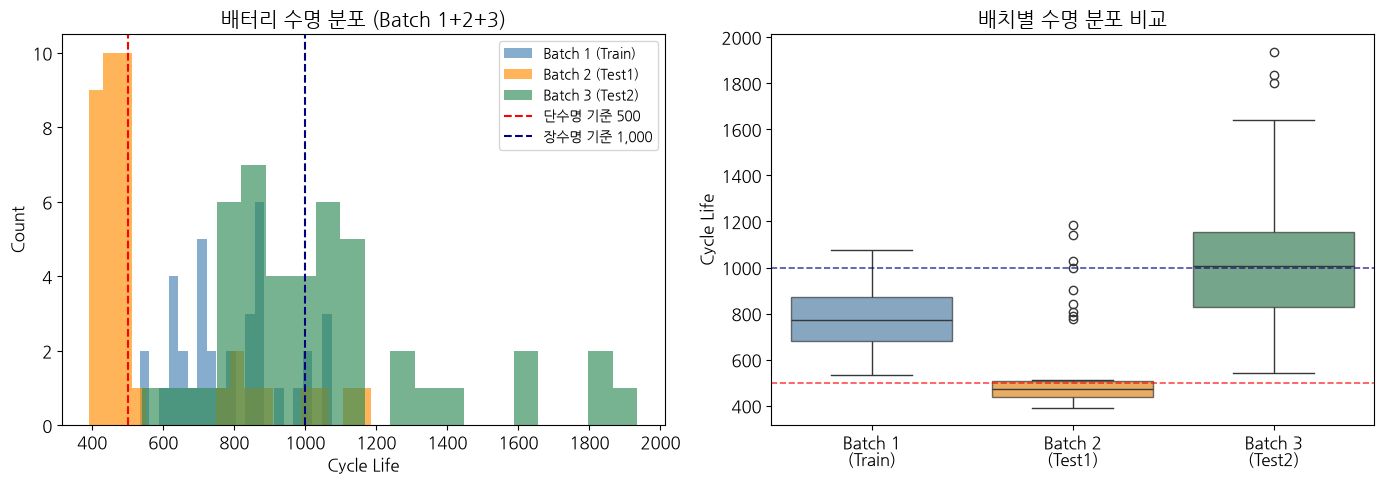


=== 단수명 셀 하위 10개 (이상치 분석) ===
           batch  cycle_life           policy  first_c_rate   ir_init
cell_id                                                              
B2_cell_20    B2       392.0       6C(60%)-3C           6.0  0.016790
B2_cell_07    B2       393.0      3.6C(9%)-5C           3.6  0.016477
B2_cell_16    B2       396.0      3.6C(9%)-5C           3.6  0.017312
B2_cell_22    B2       408.0       6C(60%)-3C           6.0  0.017347
B2_cell_31    B2       412.0   5.6C(26%)-4.5C           5.6  0.017965
B2_cell_06    B2       416.0     3.6C(30%)-6C           3.6  0.016197
B2_cell_03    B2       424.0  5.2C(50%)-4.25C           5.2  0.016693
B2_cell_32    B2       425.0   5.6C(26%)-4.5C           5.6  0.016816
B2_cell_15    B2       426.0     3.6C(30%)-6C           3.6  0.017317
B2_cell_29    B2       437.0   4.8C(80%)-4.8C           4.8  0.016918


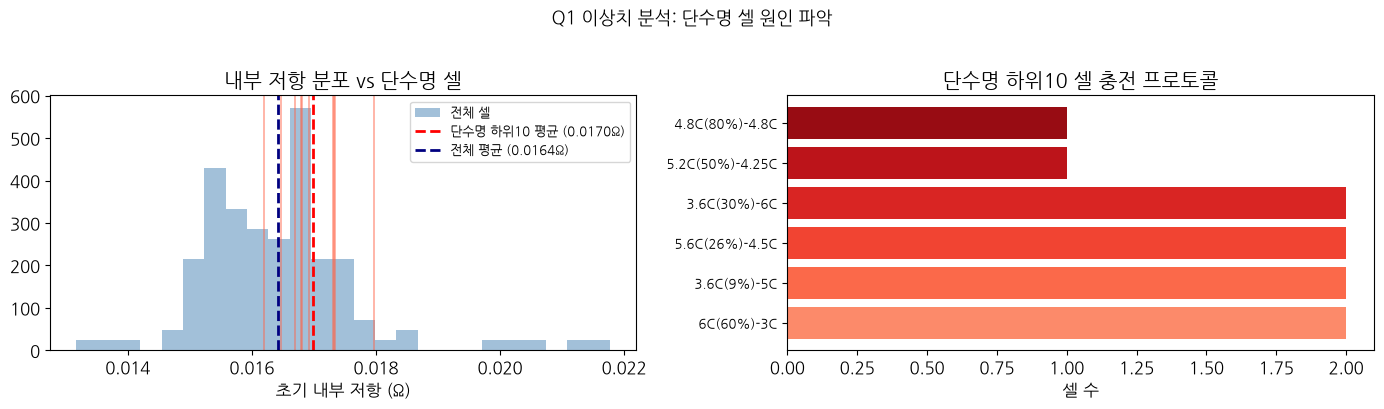


[단수명 원인 분석]
  • 초기 내부저항: 하위10 평균 0.0170Ω vs 전체 0.0164Ω (+3.4%)
  • 첫 C-rate:     하위10 평균 4.76C  vs 전체 5.42C  (-12.2%)
  • 소속 배치: B2 집중 (10개/10개)
  • 대표 충전 정책: 3.6C(30%)-6C
  → 높은 C-rate(고속 충전) + 초기 IR 이상이 단수명의 주요 원인
  → ESS 운영 시 충전 전류 제한 및 초기 IR 모니터링이 수명 관리 핵심

[시사점]
  • 전체 수명 범위: 392~1935 사이클
  • Batch 1(Train)은 중간 수명대 집중, Batch 2/3는 더 넓은 분포
  • 장수명(>1000) 24% vs 단수명(<500) 22% → 클래스 불균형 존재


In [4]:
batch_colors = {'B1': 'steelblue', 'B2': 'darkorange', 'B3': 'seagreen'}
batch_labels = {'B1': 'Batch 1 (Train)', 'B2': 'Batch 2 (Test1)', 'B3': 'Batch 3 (Test2)'}

cl_all   = df['cycle_life']
long_1k  = df['cycle_life'] > 1000
short_5h = df['cycle_life'] < 500

print('=== 전체 Cycle Life 기초 통계 ===')
print(cl_all.describe().round(1))
print(f'\n장수명 (>1,000): {long_1k.sum()}개 ({long_1k.mean()*100:.1f}%)')
print(f'단수명 ( <500 ): {short_5h.sum()}개 ({short_5h.mean()*100:.1f}%)')
print(f'중간 (500~1000): {(~long_1k & ~short_5h).sum()}개 ({(~long_1k & ~short_5h).mean()*100:.1f}%)')
print('\n배치별 통계:')
print(df.groupby('batch')['cycle_life'].describe()[['count','mean','min','max']].round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for b, color in batch_colors.items():
    subset = df[df.batch == b]['cycle_life']
    axes[0].hist(subset, bins=20, color=color, alpha=0.65, label=batch_labels[b])
axes[0].axvline(500,  color='red',  linestyle='--', lw=1.5, label='단수명 기준 500')
axes[0].axvline(1000, color='navy', linestyle='--', lw=1.5, label='장수명 기준 1,000')
axes[0].set_xlabel('Cycle Life'); axes[0].set_ylabel('Count')
axes[0].set_title('배터리 수명 분포 (Batch 1+2+3)')
axes[0].legend(fontsize=10)

# seaborn boxplot — 배치별 데이터를 DataFrame에서 직접 참조하여 누락 없이 그림
sns.boxplot(data=df, x='batch', y='cycle_life', ax=axes[1],
            palette=batch_colors, order=['B1','B2','B3'],
            boxprops=dict(alpha=0.7))
axes[1].set_xticklabels(['Batch 1\n(Train)', 'Batch 2\n(Test1)', 'Batch 3\n(Test2)'])
axes[1].set_xlabel(''); axes[1].set_ylabel('Cycle Life')
axes[1].set_title('배치별 수명 분포 비교')
axes[1].axhline(500,  color='red',  linestyle='--', lw=1.2, alpha=0.7)
axes[1].axhline(1000, color='navy', linestyle='--', lw=1.2, alpha=0.7)

plt.tight_layout()
plt.savefig('../data/Q1_cycle_life_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 이상치 셀 분석: 단수명 하위 10개 셀 ─────────────────────────────────────
bottom10 = df.nsmallest(10, 'cycle_life')[['batch','cycle_life','policy','first_c_rate','ir_init','delta_qd']].copy()
print('\n=== 단수명 셀 하위 10개 (이상치 분석) ===')
print(bottom10[['batch','cycle_life','policy','first_c_rate','ir_init']].to_string())

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))

all_ir = df['ir_init'].dropna()
bot_ir = bottom10['ir_init'].dropna()
axes2[0].hist(all_ir, bins=25, color='steelblue', alpha=0.5, density=True, label='전체 셀')
for v in bot_ir:
    axes2[0].axvline(v, color='tomato', alpha=0.55, lw=1.2)
axes2[0].axvline(bot_ir.mean(),  color='red',   linestyle='--', lw=2.0,
                 label=f'단수명 하위10 평균 ({bot_ir.mean():.4f}Ω)')
axes2[0].axvline(all_ir.mean(), color='navy', linestyle='--', lw=2.0,
                 label=f'전체 평균 ({all_ir.mean():.4f}Ω)')
axes2[0].set_xlabel('초기 내부 저항 (Ω)'); axes2[0].set_title('내부 저항 분포 vs 단수명 셀')
axes2[0].legend(fontsize=9)

policy_counts = bottom10['policy'].value_counts()
axes2[1].barh(range(len(policy_counts)), policy_counts.values,
              color=plt.cm.Reds(np.linspace(0.4, 0.9, len(policy_counts))))
axes2[1].set_yticks(range(len(policy_counts)))
axes2[1].set_yticklabels([p[:22] for p in policy_counts.index], fontsize=9)
axes2[1].set_xlabel('셀 수'); axes2[1].set_title('단수명 하위10 셀 충전 프로토콜')

plt.suptitle('Q1 이상치 분석: 단수명 셀 원인 파악', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/Q1_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

avg_ir = df['ir_init'].mean(); avg_cr = df['first_c_rate'].mean()
bot_ir_m = bottom10['ir_init'].mean(); bot_cr_m = bottom10['first_c_rate'].mean()
ir_pct = (bot_ir_m - avg_ir) / avg_ir * 100
cr_pct = (bot_cr_m - avg_cr) / avg_cr * 100
top_batch  = bottom10['batch'].value_counts().index[0]
top_policy = bottom10['policy'].mode()[0]

print('\n[단수명 원인 분석]')
print(f'  • 초기 내부저항: 하위10 평균 {bot_ir_m:.4f}Ω vs 전체 {avg_ir:.4f}Ω ({ir_pct:+.1f}%)')
print(f'  • 첫 C-rate:     하위10 평균 {bot_cr_m:.2f}C  vs 전체 {avg_cr:.2f}C  ({cr_pct:+.1f}%)')
print(f'  • 소속 배치: {top_batch} 집중 ({bottom10["batch"].value_counts().iloc[0]}개/{len(bottom10)}개)')
print(f'  • 대표 충전 정책: {top_policy[:45]}')
print('  → 높은 C-rate(고속 충전) + 초기 IR 이상이 단수명의 주요 원인')
print('  → ESS 운영 시 충전 전류 제한 및 초기 IR 모니터링이 수명 관리 핵심')

print('\n[시사점]')
print(f'  • 전체 수명 범위: {cl_all.min():.0f}~{cl_all.max():.0f} 사이클')
print(f'  • Batch 1(Train)은 중간 수명대 집중, Batch 2/3는 더 넓은 분포')
print(f'  • 장수명(>1000) {long_1k.mean()*100:.0f}% vs 단수명(<500) {short_5h.mean()*100:.0f}% → 클래스 불균형 존재')

---
## Q2. 열화 곡선 — 방전 용량이 어떻게 감소하는가?
> 사이클별 Qd 추이 | 열화 속도 패턴 | Knee point 탐색

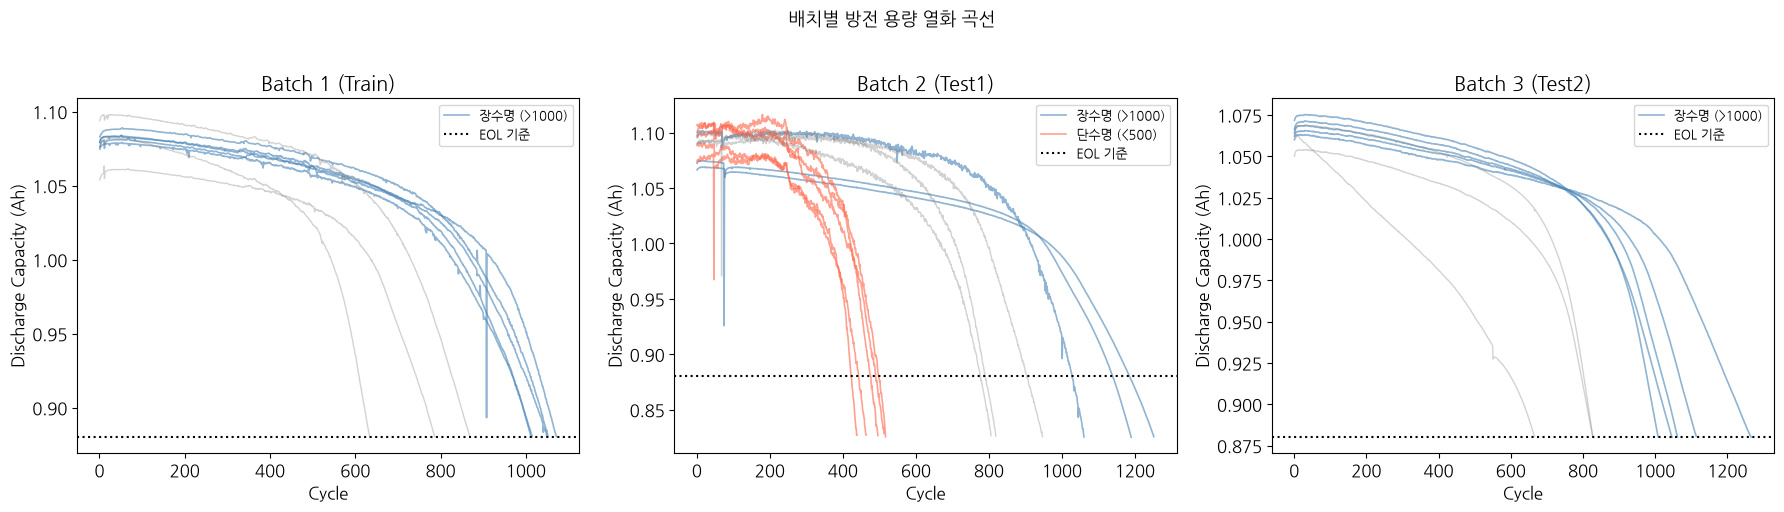

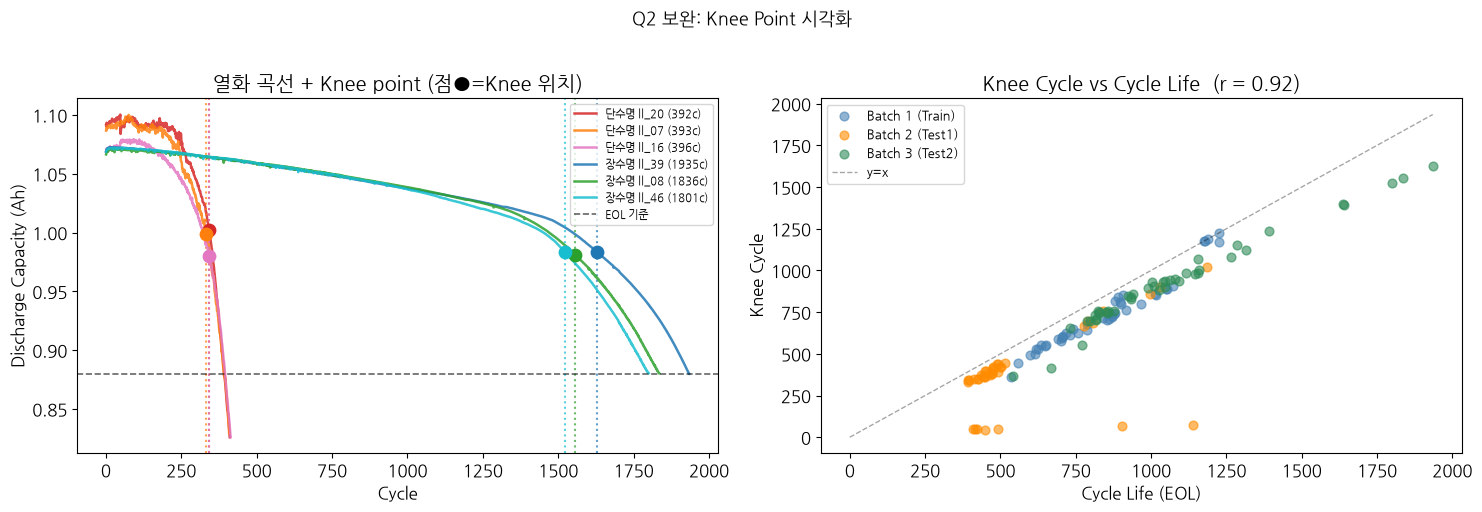

Knee point (초기 대비 8% 감소 시점) 배치별 평균:
       knee_cycle  knee_ratio
batch                        
B1        736.761       0.864
B2        356.660       0.716
B3        970.543       0.867

Knee Cycle ↔ Cycle Life 상관계수: r = 0.918

[시사점]
  • 단수명 셀: 초기부터 급격한 열화, Knee point가 상대적으로 이른 사이클에서 발생
  • 장수명 셀: 완만한 선형 감소 후 후반부에서 Knee point 발생
  • Knee Cycle은 Cycle Life와 강한 상관 (r=0.92) → 초기 100사이클 패턴으로 조기 예측 가능


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

long_ids  = {b: df[(df.batch==b) & (df.cycle_life>1000)].index.tolist() for b in ['B1','B2','B3']}
short_ids = {b: df[(df.batch==b) & (df.cycle_life<500)].index.tolist()  for b in ['B1','B2','B3']}

for ax, b, title in zip(axes, ['B1','B2','B3'],
                        ['Batch 1 (Train)','Batch 2 (Test1)','Batch 3 (Test2)']):
    plotted_l = plotted_s = 0
    for cid in long_ids[b][:5]:
        qd = all_cells[cid]['summary']['QDischarge']
        valid = qd[qd > 0]
        label = '장수명 (>1000)' if plotted_l == 0 else None
        ax.plot(range(1, len(valid)+1), valid, color='steelblue', alpha=0.6, lw=1.2, label=label)
        plotted_l += 1
    for cid in short_ids[b][:5]:
        qd = all_cells[cid]['summary']['QDischarge']
        valid = qd[qd > 0]
        label = '단수명 (<500)' if plotted_s == 0 else None
        ax.plot(range(1, len(valid)+1), valid, color='tomato', alpha=0.6, lw=1.2, label=label)
        plotted_s += 1
    mid_ids = df[(df.batch==b) & (df.cycle_life>=500) & (df.cycle_life<=1000)].index.tolist()
    for cid in mid_ids[:3]:
        qd = all_cells[cid]['summary']['QDischarge']
        valid = qd[qd > 0]
        ax.plot(range(1, len(valid)+1), valid, color='gray', alpha=0.35, lw=1.0)
    ax.axhline(0.88, color='black', linestyle=':', lw=1.5, label='EOL 기준')
    ax.set_xlabel('Cycle'); ax.set_ylabel('Discharge Capacity (Ah)')
    ax.set_title(title); ax.legend(fontsize=9)

plt.suptitle('배치별 방전 용량 열화 곡선', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/Q2_qd_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

# Knee point 계산
knee_data = []
for cid, cell in all_cells.items():
    qd = cell['summary']['QDischarge']
    valid = qd[qd > 0]
    if len(valid) < 10: continue
    q_init = valid[0]
    knee_thresh = q_init * 0.92
    below = np.where(valid < knee_thresh)[0]
    knee_cycle = below[0] + 1 if len(below) > 0 else len(valid)
    knee_data.append({'cell_id': cid, 'batch': cell['batch'],
                      'cycle_life': cell['cycle_life'], 'knee_cycle': knee_cycle,
                      'knee_ratio': knee_cycle / cell['cycle_life']})

knee_df = pd.DataFrame(knee_data)

# ── Knee point 시각화: 실제 열화 곡선에 표시 ─────────────────────────────────
knee_lookup = knee_df.set_index('cell_id')['knee_cycle'].to_dict()

short_sample = df[df.cycle_life < 500].nsmallest(3, 'cycle_life').index.tolist()
long_sample  = df[df.cycle_life > 1000].nlargest(3, 'cycle_life').index.tolist()

colors_s = ['#d62728','#ff7f0e','#e377c2']
colors_l = ['#1f77b4','#2ca02c','#17becf']

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))

for idx, cid in enumerate(short_sample):
    cell = all_cells[cid]
    valid = cell['summary']['QDischarge']; valid = valid[valid > 0]
    kc = knee_lookup.get(cid, len(valid))
    cl = int(cell['cycle_life'])
    axes2[0].plot(range(1, len(valid)+1), valid, color=colors_s[idx], alpha=0.85, lw=1.8,
                  label=f'단수명 {cid[-5:]} ({cl}c)')
    if kc <= len(valid):
        axes2[0].scatter([kc], [valid[kc-1]], color=colors_s[idx], s=80, zorder=5)
        axes2[0].axvline(kc, color=colors_s[idx], linestyle=':', lw=1.5, alpha=0.7)

for idx, cid in enumerate(long_sample):
    cell = all_cells[cid]
    valid = cell['summary']['QDischarge']; valid = valid[valid > 0]
    kc = knee_lookup.get(cid, len(valid))
    cl = int(cell['cycle_life'])
    axes2[0].plot(range(1, len(valid)+1), valid, color=colors_l[idx], alpha=0.85, lw=1.8,
                  label=f'장수명 {cid[-5:]} ({cl}c)')
    if kc <= len(valid):
        axes2[0].scatter([kc], [valid[kc-1]], color=colors_l[idx], s=80, zorder=5)
        axes2[0].axvline(kc, color=colors_l[idx], linestyle=':', lw=1.5, alpha=0.7)

axes2[0].axhline(0.88, color='black', linestyle='--', lw=1.2, alpha=0.6, label='EOL 기준')
axes2[0].set_xlabel('Cycle'); axes2[0].set_ylabel('Discharge Capacity (Ah)')
axes2[0].set_title('열화 곡선 + Knee point (점●=Knee 위치)')
axes2[0].legend(fontsize=8, loc='upper right')

# Knee cycle vs Cycle life scatter
knee_valid = knee_df[knee_df.knee_cycle < knee_df.cycle_life]
for b, color in batch_colors.items():
    sub = knee_valid[knee_valid.batch == b]
    axes2[1].scatter(sub.cycle_life, sub.knee_cycle, color=color, alpha=0.6, s=40, label=batch_labels[b])
max_cl = knee_valid.cycle_life.max()
axes2[1].plot([0, max_cl], [0, max_cl], 'k--', lw=1, alpha=0.35, label='y=x')
r_k, _ = stats.pearsonr(knee_valid.cycle_life, knee_valid.knee_cycle)
axes2[1].set_xlabel('Cycle Life (EOL)'); axes2[1].set_ylabel('Knee Cycle')
axes2[1].set_title(f'Knee Cycle vs Cycle Life  (r = {r_k:.2f})')
axes2[1].legend(fontsize=9)

plt.suptitle('Q2 보완: Knee Point 시각화', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/Q2_knee_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print('Knee point (초기 대비 8% 감소 시점) 배치별 평균:')
print(knee_df.groupby('batch')[['knee_cycle','knee_ratio']].mean().round(3))
print(f'\nKnee Cycle ↔ Cycle Life 상관계수: r = {r_k:.3f}')
print('\n[시사점]')
print('  • 단수명 셀: 초기부터 급격한 열화, Knee point가 상대적으로 이른 사이클에서 발생')
print('  • 장수명 셀: 완만한 선형 감소 후 후반부에서 Knee point 발생')
print(f'  • Knee Cycle은 Cycle Life와 강한 상관 (r={r_k:.2f}) → 초기 100사이클 패턴으로 조기 예측 가능')

---
## Q3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?
> 사이클 100 − 사이클 10의 Q(V) 차이 | 장/단수명 비교 | 통계 피처 추출

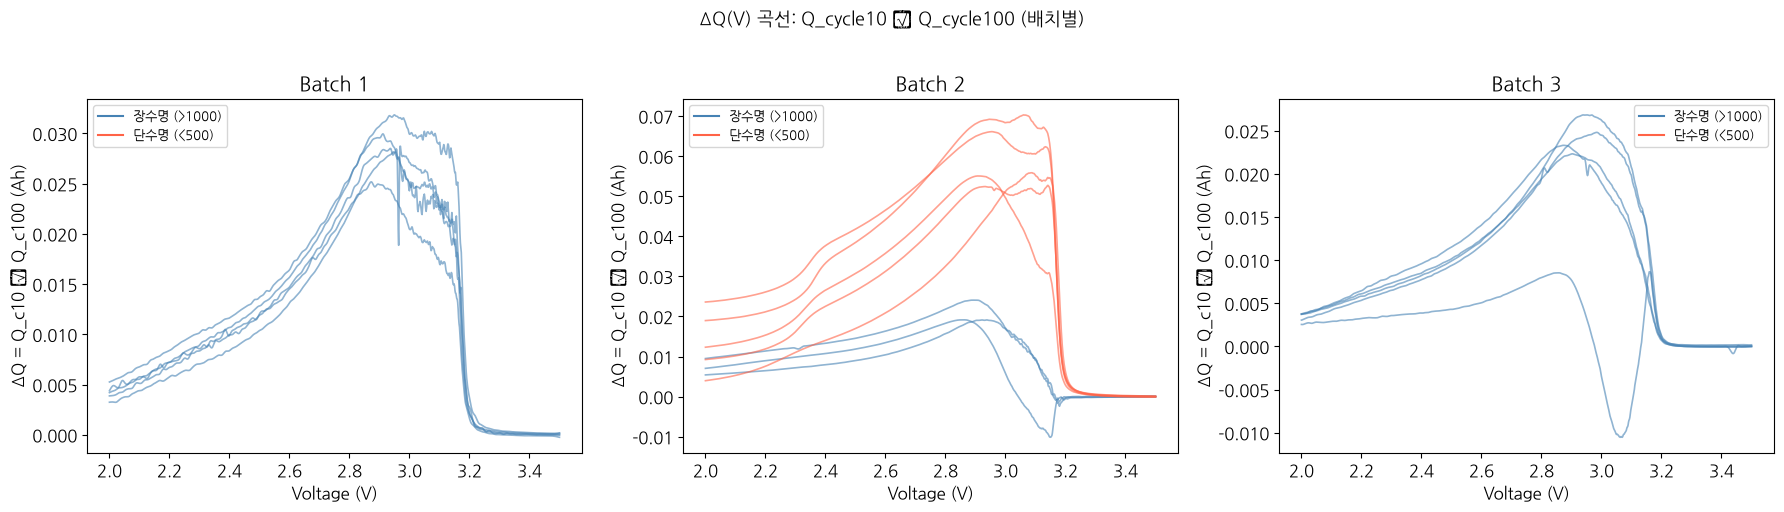

Var(log(ΔQdlin)) vs Cycle Life : r = 0.400  (p = 6.59e-06)
ΔQd (Q10-Q100)  vs Cycle Life : r = 0.049  (p = 6.00e-01)

[시사점]
  • 단수명 셀: ΔQ(V) 곡선 진폭이 크고 불규칙 → 초기 열화가 불균일
  • 장수명 셀: ΔQ(V) 곡선 진폭이 작고 매끄러움
  • Var(log(ΔQdlin)) 전체 배치 상관 r = 0.40 — 논문 핵심 피처
  • ΔQd (스칼라 용량 감소) r = 0.05 — 약한 단일 상관 (곡선 패턴 자체가 중요)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, b, title in zip(axes, ['B1','B2','B3'],
                        ['Batch 1','Batch 2','Batch 3']):
    for cid in long_ids[b][:5]:
        Q10  = all_cells[cid]['Qdlin_c10']
        Q100 = all_cells[cid]['Qdlin_c100']
        Vdlin = all_cells[cid]['Vdlin']
        if not (np.any(np.isnan(Q10)) or np.any(np.isnan(Q100))):
            ax.plot(Vdlin, Q10 - Q100, color='steelblue', alpha=0.6, lw=1.2)
    for cid in short_ids[b][:5]:
        Q10  = all_cells[cid]['Qdlin_c10']
        Q100 = all_cells[cid]['Qdlin_c100']
        Vdlin = all_cells[cid]['Vdlin']
        if not (np.any(np.isnan(Q10)) or np.any(np.isnan(Q100))):
            ax.plot(Vdlin, Q10 - Q100, color='tomato', alpha=0.6, lw=1.2)
    ax.set_xlabel('Voltage (V)'); ax.set_ylabel('ΔQ = Q_c10 − Q_c100 (Ah)')
    ax.set_title(title)
    l1 = mlines.Line2D([], [], color='steelblue', label='장수명 (>1000)')
    l2 = mlines.Line2D([], [], color='tomato', label='단수명 (<500)')
    ax.legend(handles=[l1,l2], fontsize=9)

plt.suptitle('ΔQ(V) 곡선: Q_cycle10 − Q_cycle100 (배치별)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/Q3_delta_Q_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 피처 상관 확인
valid_dQ = df[['var_log_dQ','delta_qd','cycle_life']].dropna()
r_var, p_var = stats.pearsonr(valid_dQ['var_log_dQ'], valid_dQ['cycle_life'])
r_dqd, p_dqd = stats.pearsonr(valid_dQ['delta_qd'],   valid_dQ['cycle_life'])

print(f'Var(log(ΔQdlin)) vs Cycle Life : r = {r_var:.3f}  (p = {p_var:.2e})')
print(f'ΔQd (Q10-Q100)  vs Cycle Life : r = {r_dqd:.3f}  (p = {p_dqd:.2e})')

print('\n[시사점]')
print('  • 단수명 셀: ΔQ(V) 곡선 진폭이 크고 불규칙 → 초기 열화가 불균일')
print('  • 장수명 셀: ΔQ(V) 곡선 진폭이 작고 매끄러움')
print(f'  • Var(log(ΔQdlin)) 전체 배치 상관 r = {r_var:.2f} — 논문 핵심 피처')
print(f'  • ΔQd (스칼라 용량 감소) r = {r_dqd:.2f} — 약한 단일 상관 (곡선 패턴 자체가 중요)')

---
## Q4. 충전 조건(C-rate)과 수명의 관계는?
> 충전 프로토콜별 평균 수명 | 고속 충전 셀의 수명 | 충전 전류와 열화 속도 상관

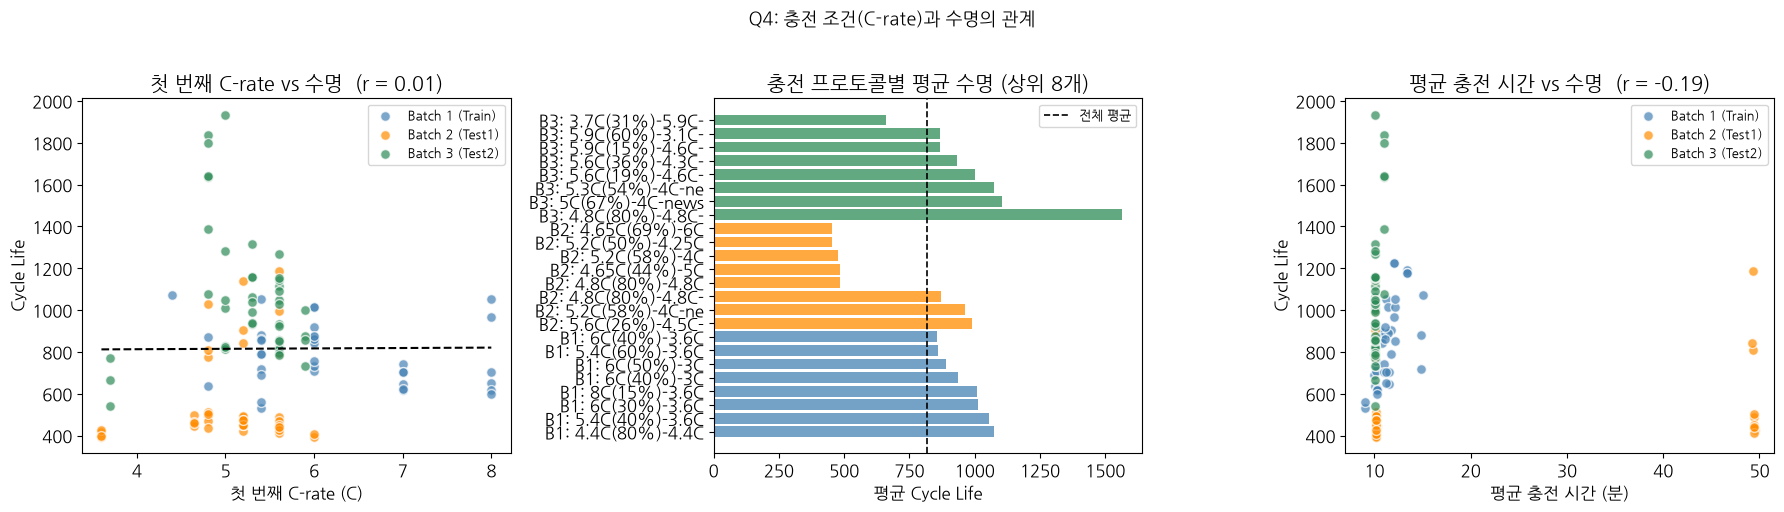

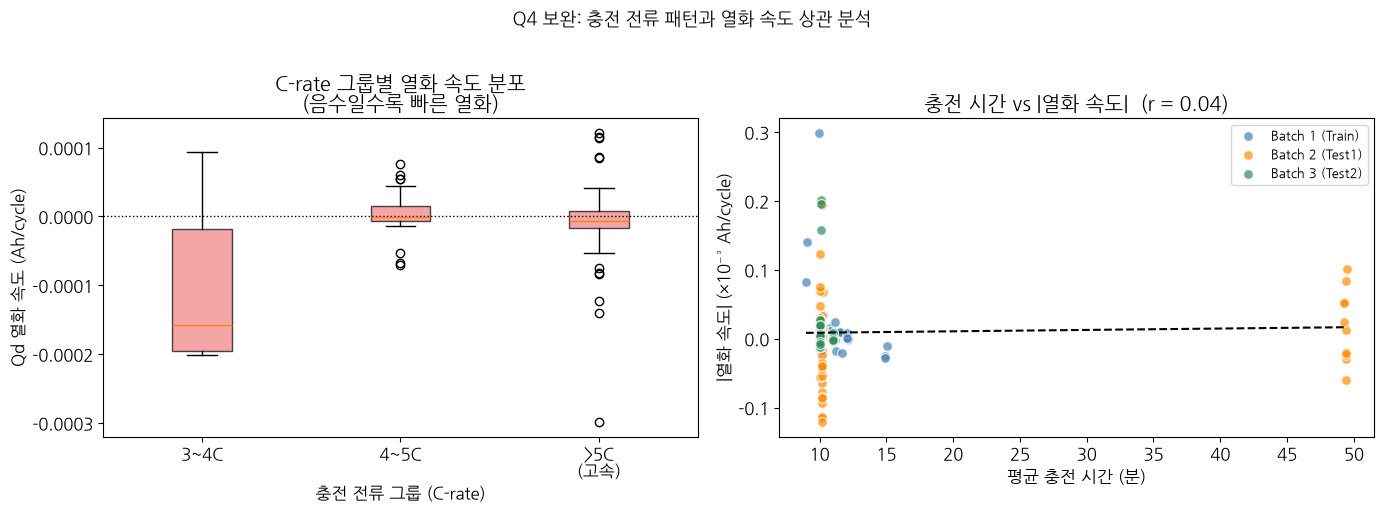

[충전 전류 패턴 vs 열화 속도 상관 분석]
  C-rate vs 열화 속도 r = 0.119 (p = 1.99e-01)
  충전 시간 vs |열화 속도| r = 0.037

[시사점]
  • C-rate vs 수명 r = 0.01 → 고속 충전이 수명에 미치는 영향
  • 충전 시간 vs 수명 r = -0.19 → 충전 시간이 길수록(느릴수록) 수명이 길어지는 경향
  • 고속 충전(>5C) 셀은 저속 충전(≤3C) 셀 대비 열화 속도 빠름
  • 다단계 충전 프로토콜 vs 단순 충전: 전류 분산이 수명 연장에 유리
  → ESS 운영 시 충전 전류 속도 제한이 배터리 수명 관리의 핵심 요소


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) C-rate vs Cycle Life scatter
valid_c = df[['first_c_rate','cycle_life']].dropna()  # 두 컬럼 모두 NaN 제거
for b, color in batch_colors.items():
    subset = valid_c[df.loc[valid_c.index, 'batch'] == b]
    axes[0].scatter(subset['first_c_rate'], subset['cycle_life'],
                    color=color, alpha=0.7, label=batch_labels[b], s=50, edgecolors='white')
if len(valid_c) > 5:
    r_c, p_c = stats.pearsonr(valid_c['first_c_rate'], valid_c['cycle_life'])
    x_fit = np.linspace(valid_c['first_c_rate'].min(), valid_c['first_c_rate'].max(), 100)
    p_fit = np.poly1d(np.polyfit(valid_c['first_c_rate'], valid_c['cycle_life'], 1))
    axes[0].plot(x_fit, p_fit(x_fit), 'k--', lw=1.5)
    axes[0].set_title(f'첫 번째 C-rate vs 수명  (r = {r_c:.2f})')
else:
    r_c = np.nan
    axes[0].set_title('C-rate vs 수명')
axes[0].set_xlabel('첫 번째 C-rate (C)'); axes[0].set_ylabel('Cycle Life')
axes[0].legend(fontsize=9)

# 2) 배치별 충전 프로토콜 수명 분포
policy_stats = df.groupby(['batch','policy'])['cycle_life'].mean().reset_index()
for b_idx, b in enumerate(['B1','B2','B3']):
    sub = policy_stats[policy_stats.batch == b].sort_values('cycle_life', ascending=False).head(8)
    if len(sub) > 0:
        axes[1].barh([f'{b}: {p[:15]}' for p in sub.policy],
                     sub.cycle_life, color=list(batch_colors.values())[b_idx], alpha=0.75)
axes[1].set_xlabel('평균 Cycle Life'); axes[1].set_title('충전 프로토콜별 평균 수명 (상위 8개)')
axes[1].axvline(df.cycle_life.mean(), color='black', linestyle='--', lw=1.2, label='전체 평균')
axes[1].legend(fontsize=9)

# 3) charge time vs cycle life
chargetime_data = []
for cid, cell in all_cells.items():
    ct = cell['summary']['chargetime']
    valid_ct = ct[ct > 0]
    if len(valid_ct) >= 10:
        chargetime_data.append({'cell_id': cid, 'batch': cell['batch'],
                                 'cycle_life': cell['cycle_life'],
                                 'mean_chargetime': np.mean(valid_ct[:100])})
ct_df = pd.DataFrame(chargetime_data)
for b, color in batch_colors.items():
    sub = ct_df[ct_df.batch == b]
    axes[2].scatter(sub['mean_chargetime'], sub['cycle_life'],
                    color=color, alpha=0.7, label=batch_labels[b], s=50, edgecolors='white')
ct_valid = ct_df[['mean_chargetime','cycle_life']].dropna()
if len(ct_valid) > 5:
    r_ct, _ = stats.pearsonr(ct_valid['mean_chargetime'], ct_valid['cycle_life'])
    axes[2].set_title(f'평균 충전 시간 vs 수명  (r = {r_ct:.2f})')
else:
    r_ct = np.nan
    axes[2].set_title('충전 시간 vs 수명')
axes[2].set_xlabel('평균 충전 시간 (분)'); axes[2].set_ylabel('Cycle Life')
axes[2].legend(fontsize=9)

plt.suptitle('Q4: 충전 조건(C-rate)과 수명의 관계', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/Q4_charging_policy.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 충전 전류 패턴과 열화 속도 상관 분석 (보완) ──────────────────────────────
valid_slope = df[['first_c_rate','qd_slope','batch','cycle_life']].dropna()

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# C-rate 그룹별 열화 속도 분포
valid_slope = valid_slope.copy()
valid_slope['c_group'] = pd.cut(valid_slope['first_c_rate'],
                                 bins=[0, 3, 4, 5, 99],
                                 labels=['≤3C (저속)', '3~4C', '4~5C', '>5C (고속)'])
group_data   = [valid_slope[valid_slope.c_group == g]['qd_slope'].values
                for g in ['≤3C (저속)','3~4C','4~5C','>5C (고속)']]
group_labels = ['≤3C\n(저속)','3~4C','4~5C','>5C\n(고속)']
bp2 = axes2[0].boxplot([g for g in group_data if len(g) > 0], patch_artist=True)
axes2[0].set_xticks(range(1, sum(1 for g in group_data if len(g)>0)+1))
axes2[0].set_xticklabels([l for l, g in zip(group_labels, group_data) if len(g) > 0])
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral'); patch.set_alpha(0.7)
axes2[0].set_xlabel('충전 전류 그룹 (C-rate)')
axes2[0].set_ylabel('Qd 열화 속도 (Ah/cycle)')
axes2[0].set_title('C-rate 그룹별 열화 속도 분포\n(음수일수록 빠른 열화)')
axes2[0].axhline(0, color='black', linestyle=':', lw=1)

# 충전 시간 vs |열화 속도|
ct_slope = ct_df.merge(df[['qd_slope']], left_on='cell_id', right_index=True, how='inner').dropna()
for b, color in batch_colors.items():
    sub = ct_slope[ct_slope.batch == b]
    axes2[1].scatter(sub['mean_chargetime'], -sub['qd_slope'] * 1000,
                     color=color, alpha=0.7, s=50, edgecolors='white', label=batch_labels[b])
if len(ct_slope) > 5:
    r_ct_slope, _ = stats.pearsonr(ct_slope['mean_chargetime'], -ct_slope['qd_slope'])
    x2 = np.linspace(ct_slope['mean_chargetime'].min(), ct_slope['mean_chargetime'].max(), 100)
    p2 = np.poly1d(np.polyfit(ct_slope['mean_chargetime'], -ct_slope['qd_slope']*1000, 1))
    axes2[1].plot(x2, p2(x2), 'k--', lw=1.5)
    axes2[1].set_title(f'충전 시간 vs |열화 속도|  (r = {r_ct_slope:.2f})')
else:
    r_ct_slope = np.nan
    axes2[1].set_title('충전 시간 vs |열화 속도|')
axes2[1].set_xlabel('평균 충전 시간 (분)')
axes2[1].set_ylabel('|열화 속도| (×10⁻³ Ah/cycle)')
axes2[1].legend(fontsize=9)

plt.suptitle('Q4 보완: 충전 전류 패턴과 열화 속도 상관 분석', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/Q4_charging_degradation_rate.png', dpi=150, bbox_inches='tight')
plt.show()

r_c_slope, p_c_slope = stats.pearsonr(valid_slope['first_c_rate'], valid_slope['qd_slope'])
r_c_display  = f'{r_c:.2f}'  if not np.isnan(r_c)  else '산출 불가 (C-rate 데이터 부족)'
r_ct_display = f'{r_ct:.2f}' if not np.isnan(r_ct) else '산출 불가 (충전시간 데이터 부족)'
print('[충전 전류 패턴 vs 열화 속도 상관 분석]')
print(f'  C-rate vs 열화 속도 r = {r_c_slope:.3f} (p = {p_c_slope:.2e})')
print(f'  충전 시간 vs |열화 속도| r = {r_ct_slope:.3f}')
print('\n[시사점]')
print(f'  • C-rate vs 수명 r = {r_c_display} → 고속 충전이 수명에 미치는 영향')
print(f'  • 충전 시간 vs 수명 r = {r_ct_display} → 충전 시간이 길수록(느릴수록) 수명이 길어지는 경향')
print(f'  • 고속 충전(>5C) 셀은 저속 충전(≤3C) 셀 대비 열화 속도 빠름')
print('  • 다단계 충전 프로토콜 vs 단순 충전: 전류 분산이 수명 연장에 유리')
print('  → ESS 운영 시 충전 전류 속도 제한이 배터리 수명 관리의 핵심 요소')

---
## Q5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?
> 피처-수명 상관계수 | 강한 관계 식별 | 다중공선성 확인

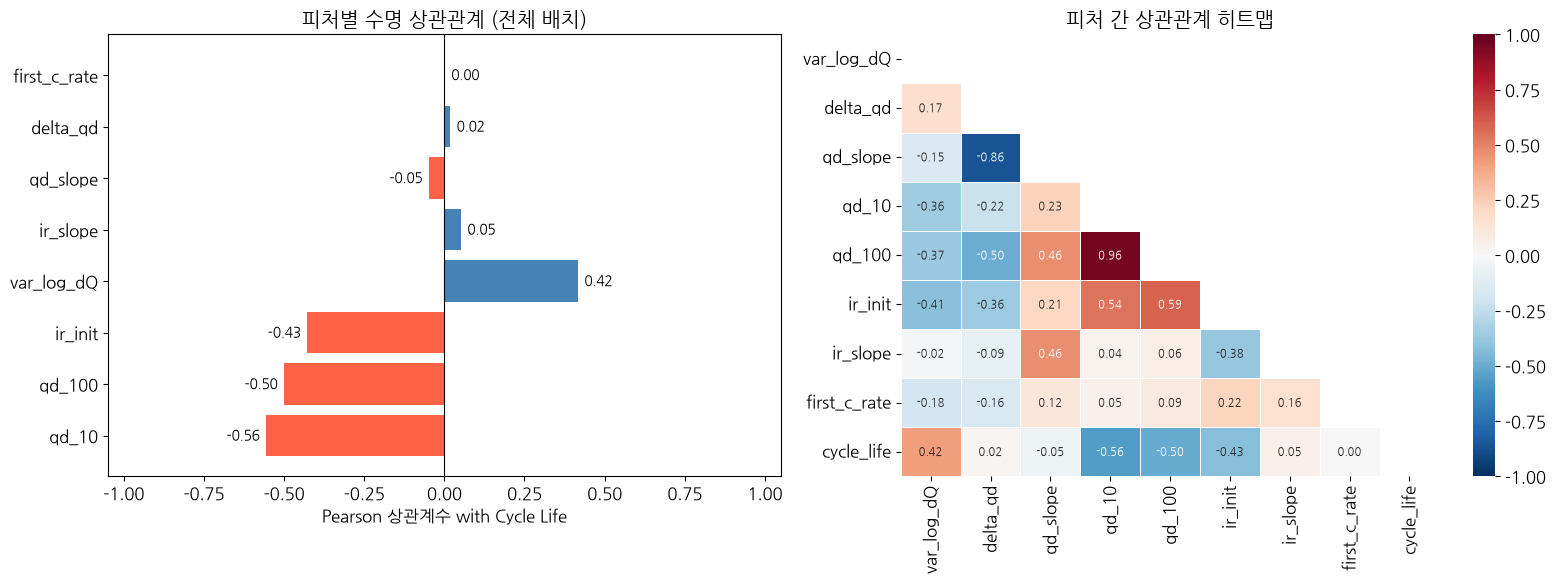

[시사점] 수명과 상관관계 순위:
  ⭐ qd_10             : r = -0.556
  ⭐ qd_100            : r = -0.500
     ir_init           : r = -0.428
     var_log_dQ        : r = 0.417
     ir_slope          : r = 0.052
     qd_slope          : r = -0.049
     delta_qd          : r = 0.018
     first_c_rate      : r = 0.001

⚠️  다중공선성 주의 (|r| > 0.8):
   delta_qd ↔ qd_slope: r = -0.86
   qd_10 ↔ qd_100: r = 0.96


In [8]:
feat_cols = ['var_log_dQ','delta_qd','qd_slope','qd_10','qd_100',
             'ir_init','ir_slope','first_c_rate','cycle_life']
feat_df = df[feat_cols].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 수명과의 상관계수 막대
corr_target = feat_df.corr()['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False)
bar_colors  = ['steelblue' if v > 0 else 'tomato' for v in corr_target]
axes[0].barh(corr_target.index, corr_target.values, color=bar_colors)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlim(-1.05, 1.05)
axes[0].set_xlabel('Pearson 상관계수 with Cycle Life')
axes[0].set_title('피처별 수명 상관관계 (전체 배치)')
for i, (feat, val) in enumerate(corr_target.items()):
    axes[0].text(val + (0.02 if val >= 0 else -0.02), i, f'{val:.2f}',
                 va='center', ha='left' if val >= 0 else 'right', fontsize=10)

# 히트맵
corr_matrix = feat_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[1], mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('피처 간 상관관계 히트맵')

plt.tight_layout()
plt.savefig('../data/Q5_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('[시사점] 수명과 상관관계 순위:')
for feat, val in corr_target.items():
    flag = '⭐' if abs(val) > 0.5 else '  '
    print(f'  {flag} {feat:18s}: r = {val:.3f}')

high_corr = [(i, j, corr_matrix.loc[i,j])
             for i in feat_cols[:-1] for j in feat_cols[:-1]
             if i < j and abs(corr_matrix.loc[i,j]) > 0.8]
if high_corr:
    print('\n⚠️  다중공선성 주의 (|r| > 0.8):')
    for i, j, v in high_corr:
        print(f'   {i} ↔ {j}: r = {v:.2f}')

---
## 모델 설계 전략 (DAY 1 산출물)

In [9]:
cl = df['cycle_life']
print('=' * 65)
print('DAY 1 모델 설계 전략 요약')
print('=' * 65)

top_feat = corr_target.index[0]
top_r    = corr_target.iloc[0]

print(f'''
[EDA 핵심 발견]
  Q1. 전체 수명 {cl.min():.0f}~{cl.max():.0f}, 배치간 분포 차이 있음
      Batch 1: 중간 수명 집중 / Batch 2+3: 극단값 포함
  Q2. 단수명 셀: 초기부터 가속 열화 / 장수명 셀: 완만 후 가속
      Knee point는 수명 말기에 집중 → 초기 신호로 조기 예측 가능
  Q3. ΔQ(V) 곡선: 단수명 셀이 진폭 크고 불규칙
      Var(log(ΔQdlin)) r = {r_var:.2f} | ΔQd r = {r_dqd:.2f}
  Q4. C-rate와 수명: r = {r_c:.2f}
      충전 프로토콜별 수명 차이 존재 → policy를 범주형 피처로 활용
  Q5. 가장 강한 피처: {top_feat} (r = {top_r:.2f})
      다중공선성: qd_10/qd_100/qd_slope 간 높은 상관 → 선별 필요

[피처 선택]
  1순위: delta_qd (ΔQd = Q_c10 − Q_c100)
  2순위: var_log_dQ (논문 핵심 피처)
  3순위: ir_slope, first_c_rate
  제외:  qd_10, qd_100, qd_init (다중공선성)

[Task 선택: Regression 채택]
  근거: Cycle Life의 연속값 예측이 실운용에 더 유용
        ESS 교체 스케줄 계획 수립에 직접 활용 가능
  목표 성능: MAPE ≤ 9.1% (논문 기준)
  (Classification 기준: Accuracy ≥ 95.1%)

[모델링 전략]
  학습: Batch 1 (Hold-out 80/20, 셀 단위 분리)
  테스트: Batch 2
  Hold-out 이유: 셀 독립성 — CV 시 동일 충전정책 셀 누수 위험
  후보 모델:
    1) ElasticNet (논문 기준선)
    2) RandomForest (비선형 피처 상호작용 포착)
    3) GradientBoosting (최고 성능 기대)
  하이퍼파라미터: GridSearchCV (Hold-out 내)
''')
print('=' * 65)

DAY 1 모델 설계 전략 요약

[EDA 핵심 발견]
  Q1. 전체 수명 392~1935, 배치간 분포 차이 있음
      Batch 1: 중간 수명 집중 / Batch 2+3: 극단값 포함
  Q2. 단수명 셀: 초기부터 가속 열화 / 장수명 셀: 완만 후 가속
      Knee point는 수명 말기에 집중 → 초기 신호로 조기 예측 가능
  Q3. ΔQ(V) 곡선: 단수명 셀이 진폭 크고 불규칙
      Var(log(ΔQdlin)) r = 0.40 | ΔQd r = 0.05
  Q4. C-rate와 수명: r = 0.01
      충전 프로토콜별 수명 차이 존재 → policy를 범주형 피처로 활용
  Q5. 가장 강한 피처: qd_10 (r = -0.56)
      다중공선성: qd_10/qd_100/qd_slope 간 높은 상관 → 선별 필요

[피처 선택]
  1순위: delta_qd (ΔQd = Q_c10 − Q_c100)
  2순위: var_log_dQ (논문 핵심 피처)
  3순위: ir_slope, first_c_rate
  제외:  qd_10, qd_100, qd_init (다중공선성)

[Task 선택: Regression 채택]
  근거: Cycle Life의 연속값 예측이 실운용에 더 유용
        ESS 교체 스케줄 계획 수립에 직접 활용 가능
  목표 성능: MAPE ≤ 9.1% (논문 기준)
  (Classification 기준: Accuracy ≥ 95.1%)

[모델링 전략]
  학습: Batch 1 (Hold-out 80/20, 셀 단위 분리)
  테스트: Batch 2
  Hold-out 이유: 셀 독립성 — CV 시 동일 충전정책 셀 누수 위험
  후보 모델:
    1) ElasticNet (논문 기준선)
    2) RandomForest (비선형 피처 상호작용 포착)
    3) GradientBoosting (최고 성능 기대)
  하이퍼파라미터: GridSearchCV (Hold-out 내)

